In [2]:
import scipy.linalg as la
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from scipy.stats import norm

Processing delta = 20841


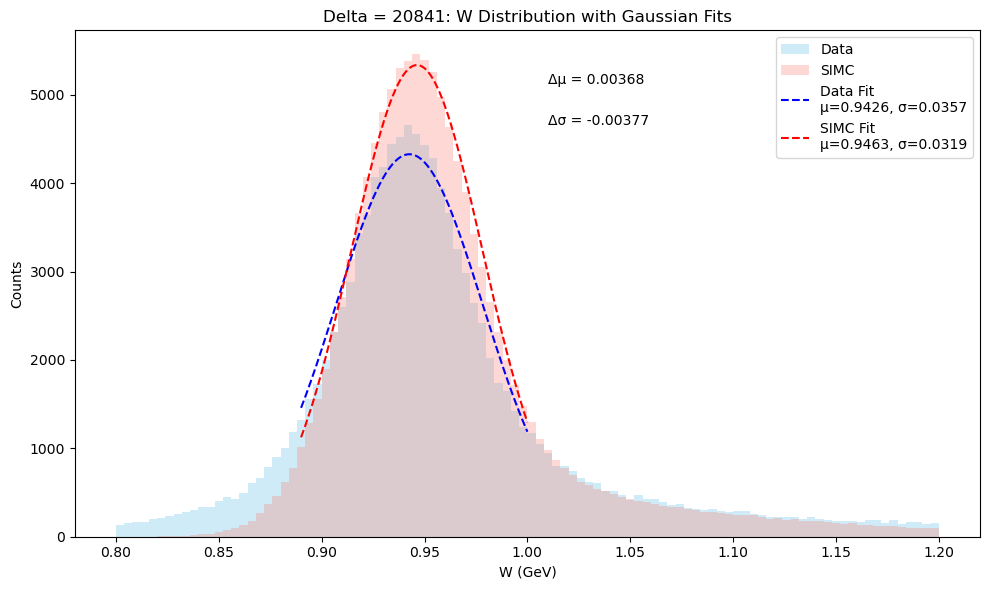

Data Fit:   Mean = 0.94263,  Sigma = 0.03568
SIMC Fit:   Mean = 0.94631,  Sigma = 0.03191
Δ Mean = 0.00368
Δ Sigma = -0.00377
Processing delta = 20846


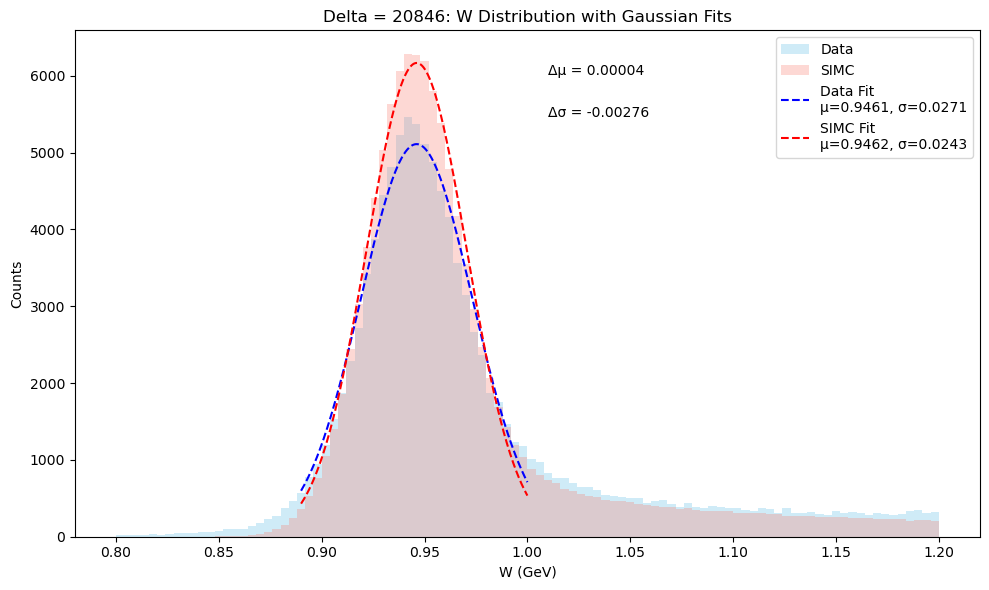

Data Fit:   Mean = 0.94614,  Sigma = 0.02711
SIMC Fit:   Mean = 0.94617,  Sigma = 0.02435
Δ Mean = 0.00004
Δ Sigma = -0.00276
Processing delta = 20851


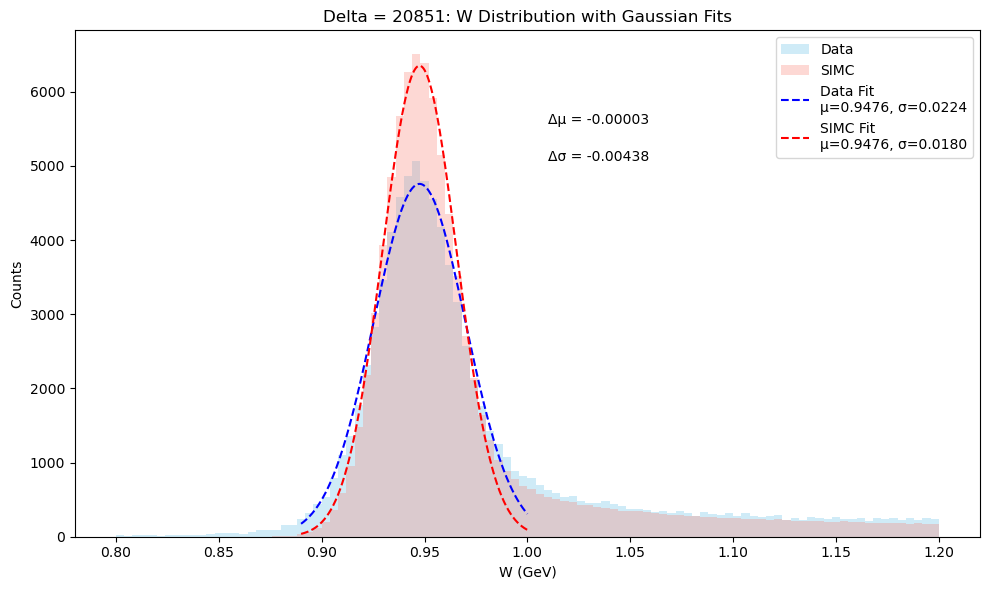

Data Fit:   Mean = 0.94759,  Sigma = 0.02240
SIMC Fit:   Mean = 0.94756,  Sigma = 0.01801
Δ Mean = -0.00003
Δ Sigma = -0.00438
Processing delta = 20858


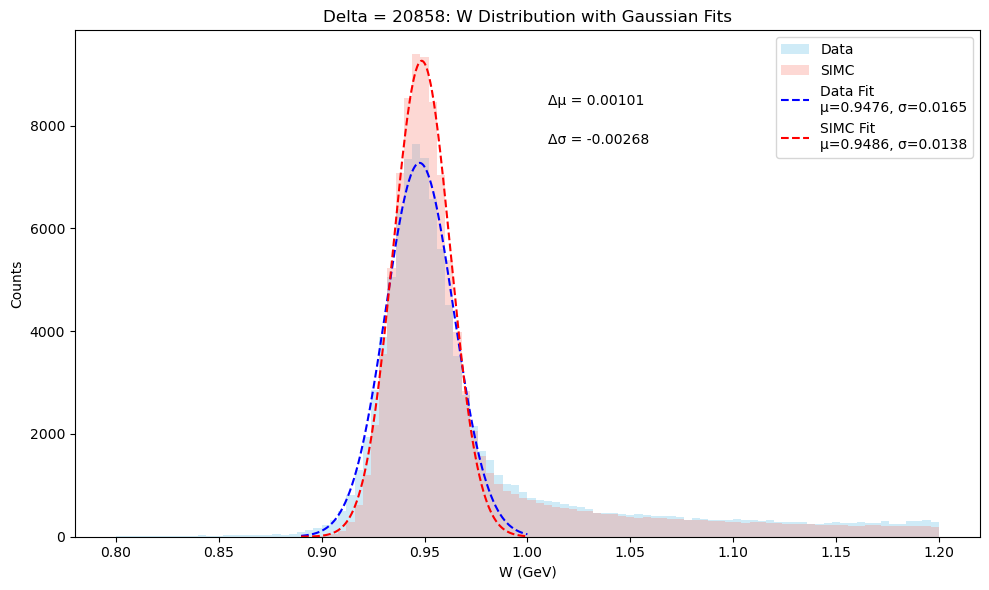

Data Fit:   Mean = 0.94760,  Sigma = 0.01652
SIMC Fit:   Mean = 0.94862,  Sigma = 0.01384
Δ Mean = 0.00101
Δ Sigma = -0.00268
Processing delta = 20861


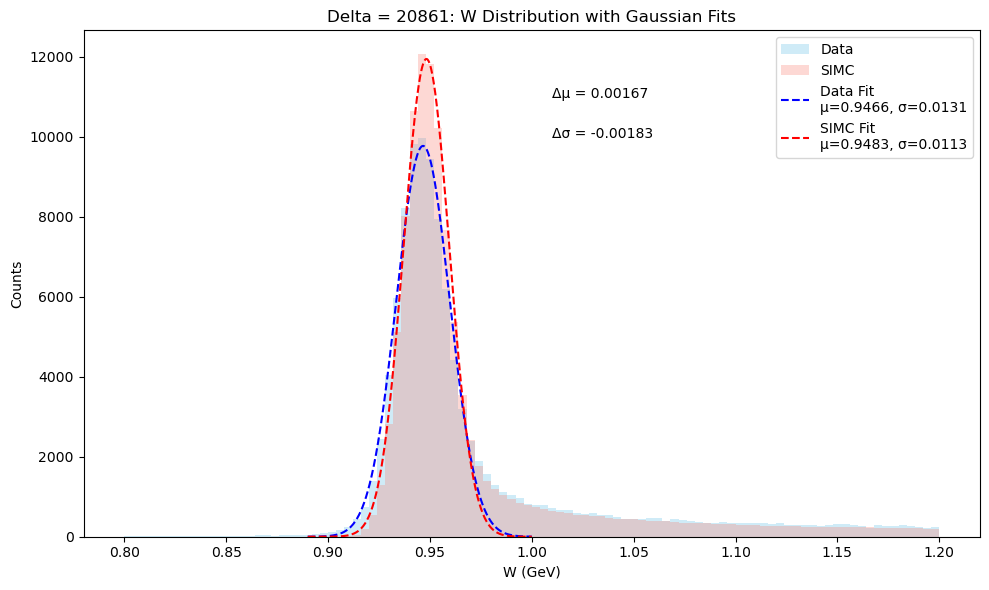

Data Fit:   Mean = 0.94660,  Sigma = 0.01308
SIMC Fit:   Mean = 0.94826,  Sigma = 0.01125
Δ Mean = 0.00167
Δ Sigma = -0.00183
Processing delta = 20869


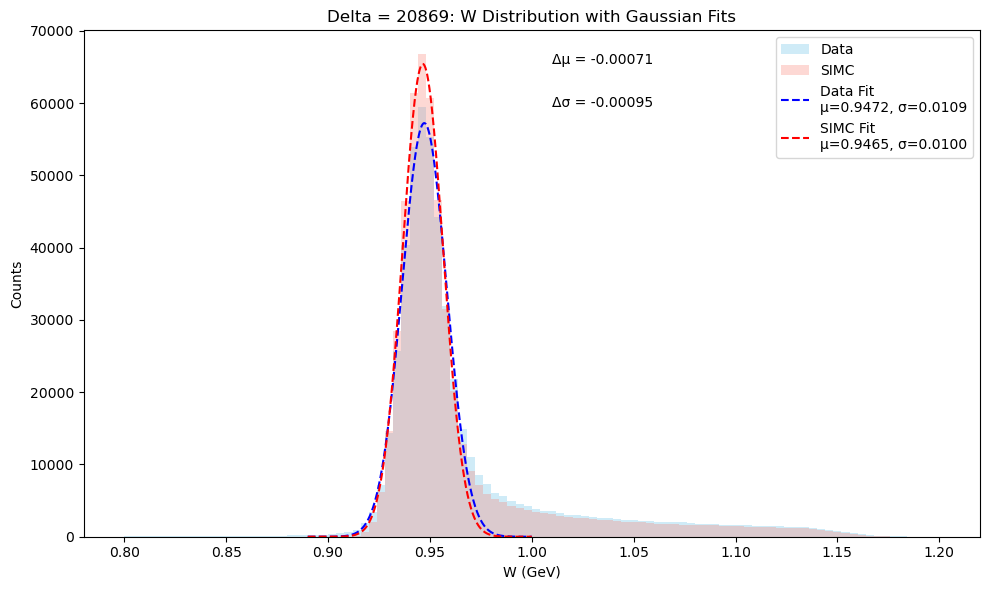

Data Fit:   Mean = 0.94721,  Sigma = 0.01092
SIMC Fit:   Mean = 0.94650,  Sigma = 0.00997
Δ Mean = -0.00071
Δ Sigma = -0.00095
✅ Saved summary to fit_W_summary.csv


In [8]:
import uproot
import numpy as np
import pandas as pd
import os
from scipy.stats import norm
from scipy.optimize import curve_fit


# List of all delta run configurations
Mp=0.938272

# Gaussian function
def gaussian(x, amplitude, mean, std_dev):
    return amplitude * np.exp(-((x - mean) ** 2) / (2 * std_dev ** 2))

runs = [
    {"Run": 20841, "data_file": "deut_20841.root", "simc_file": "d2_simc_skimmed_-8.root"},
    {"Run": 20846, "data_file": "deut_20846.root", "simc_file": "d2_simc_skimmed_-4.root"},
    {"Run": 20851, "data_file": "deut_20851.root", "simc_file": "d2_simc_skimmed_0.root"},
    {"Run": 20858, "data_file": "deut_20858.root", "simc_file": "d2_simc_skimmed_+4.root"},
    {"Run": 20861, "data_file": "deut_20861.root", "simc_file": "d2_simc_skimmed_+8.root"},
    {"Run": 20869, "data_file": "deut_20869.root", "simc_file": "d2_simc_skimmed_+12.root"},
]

# Initialize list to collect all results
results = []

for run in runs:
    print(f"Processing delta = {run['Run']}")

     # === Load data file ===
    with uproot.open(run["data_file"]) as file_data:
        tree_data = file_data["T"]
        W_data = tree_data["P.kin.primary.W"].array()
        xbj_data = tree_data["P.kin.primary.x_bj"].array()
        edelta_data = tree_data["P.gtr.dp"].array()
        hdelta_data = tree_data["H.gtr.dp"].array()
    # Apply data mask
    mask_data = (
        (xbj_data >= 0.8) & (xbj_data <= 1.2) &
        (edelta_data <= 22) & (edelta_data >= -10) &
        (hdelta_data <= 10) & (hdelta_data >= -10)
    )

     # === Load SIMC file ===
    with uproot.open(run["simc_file"]) as file_simc:
        tree_simc = file_simc["SNT"]
        W_simc = tree_simc["W"].array()
        Q2_simc = tree_simc["Q2"].array()
        nu_simc = tree_simc["nu"].array()
        edelta_simc = tree_simc["e_delta"].array()
        hdelta_simc = tree_simc["h_delta"].array()
        Weight = tree_simc["Weight"].array()
        Norm = tree_simc["Normfac"].array()

    xbj_simc = Q2_simc / (2 * Mp * nu_simc)
    FullWeight = Weight * Norm / 1_000_000

    # Apply SIMC mask
    mask_simc = (
        (xbj_simc >= 0.8) & (xbj_simc <= 1.2) &
        (edelta_simc <= 22) & (edelta_simc >= -10) &
        (hdelta_simc <= 10) & (hdelta_simc >= -10)
    )
     # --- Histogram and Fit ---
    plt.figure(figsize=(10, 6))

    # Scale weights to match data
    scale_factor = np.sum(mask_data) / np.sum(FullWeight[mask_simc])
    FullWeight_scaled = FullWeight * scale_factor

    n_data, bins_data, _ = plt.hist(W_data[mask_data], bins=100, range=(0.8, 1.2),
                                    alpha=0.4, label='Data', color='skyblue')

    n_simc, bins_simc, _ = plt.hist(W_simc[mask_simc], bins=100, range=(0.8, 1.2), alpha=0.3,
                                    weights=FullWeight_scaled[mask_simc], label='SIMC', color='salmon')

    # Bin centers
    bin_centers_data = (bins_data[:-1] + bins_data[1:]) / 2
    bin_centers_simc = (bins_simc[:-1] + bins_simc[1:]) / 2

    # Fit guesses
    init_guess_data = [np.max(n_data), bin_centers_data[np.argmax(n_data)], 0.02]
    init_guess_simc = [np.max(n_simc), bin_centers_simc[np.argmax(n_simc)], 0.02]

    # Fit Gaussians
    params_data, _ = curve_fit(gaussian, bin_centers_data, n_data, p0=init_guess_data)
    params_simc, _ = curve_fit(gaussian, bin_centers_simc, n_simc, p0=init_guess_simc)

    amp_data, mean_data, std_data = params_data
    amp_simc, mean_simc, std_simc = params_simc
    mean_diff= mean_data -mean_simc
    std_diff= std_data -std_simc
    # Generate fit curves
    x_fit = np.linspace(0.89, 1.0, 500)
    y_fit_data = gaussian(x_fit, *params_data)
    y_fit_simc = gaussian(x_fit, *params_simc)
    
     # Plot fits
    plt.plot(x_fit, y_fit_data, 'b--', label=f'Data Fit\nμ={mean_data:.4f}, σ={std_data:.4f}')
    plt.plot(x_fit, y_fit_simc, 'r--', label=f'SIMC Fit\nμ={mean_simc:.4f}, σ={std_simc:.4f}')

    # Annotate
    plt.text(1.01, max(n_data)*1.1, f"Δμ = {mean_simc - mean_data:.5f}", fontsize=10)
    plt.text(1.01, max(n_data)*1., f"Δσ = {std_simc - std_data:.5f}", fontsize=10)

    # Labels and legend
    plt.xlabel('W (GeV)')
    plt.ylabel('Counts')
    plt.title(f'Delta = {run["Run"]}: W Distribution with Gaussian Fits')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Print fit values
    print(f"Data Fit:   Mean = {mean_data:.5f},  Sigma = {std_data:.5f}")
    print(f"SIMC Fit:   Mean = {mean_simc:.5f},  Sigma = {std_simc:.5f}")
    print(f"Δ Mean = {mean_simc - mean_data:.5f}")
    print(f"Δ Sigma = {std_simc - std_data:.5f}")
    # --- Store result for this run ---
    results.append({
        "Runs": run["Run"],
        "W_data": mean_data,
        "W_data_err": std_data,
        "W_simc": mean_simc,
        "W_simc_err": std_simc,
    })

# --- Write all results to CSV ---
df = pd.DataFrame(results)
df.to_csv("fit_W_summary.csv", index=False)
print("✅ Saved summary to fit_W_summary.csv")


In [9]:
df

,Runs,W_data,W_data_err,W_simc,W_simc_err
0,20841,0.942629,0.035678,0.946306,0.031907
1,20846,0.946139,0.027109,0.946175,0.024345
2,20851,0.947592,0.022397,0.947565,0.018014
3,20858,0.947603,0.016518,0.948616,0.013839
4,20861,0.946596,0.013084,0.948262,0.011250
5,20869,0.947206,0.010925,0.946500,0.009972


Processing delta = 20841


/var/folders/2h/5v3tch6n7735dls3wck0tbr00000gn/T/ipykernel_16938/3730847972.py:112: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


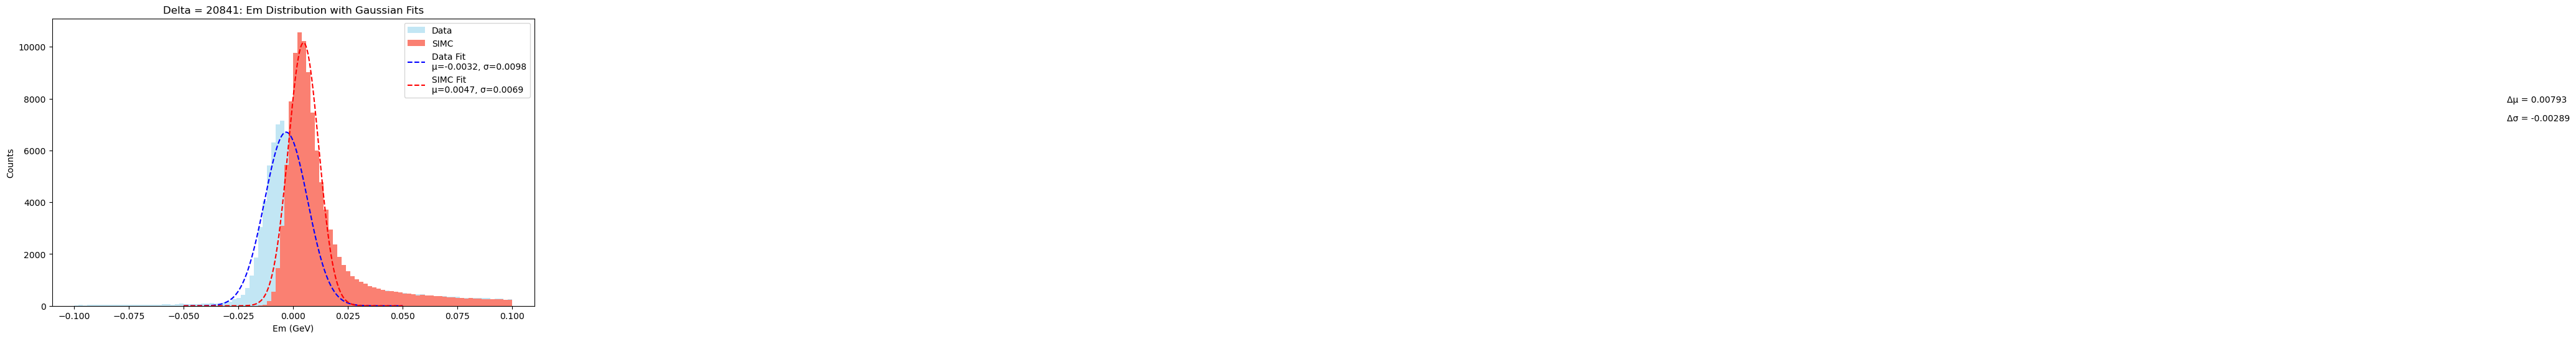

Data Fit:   Mean = -0.00320,  Sigma = 0.00982
SIMC Fit:   Mean = 0.00473,  Sigma = 0.00693
Δ Mean = 0.00793
Δ Sigma = -0.00289
Processing delta = 20846


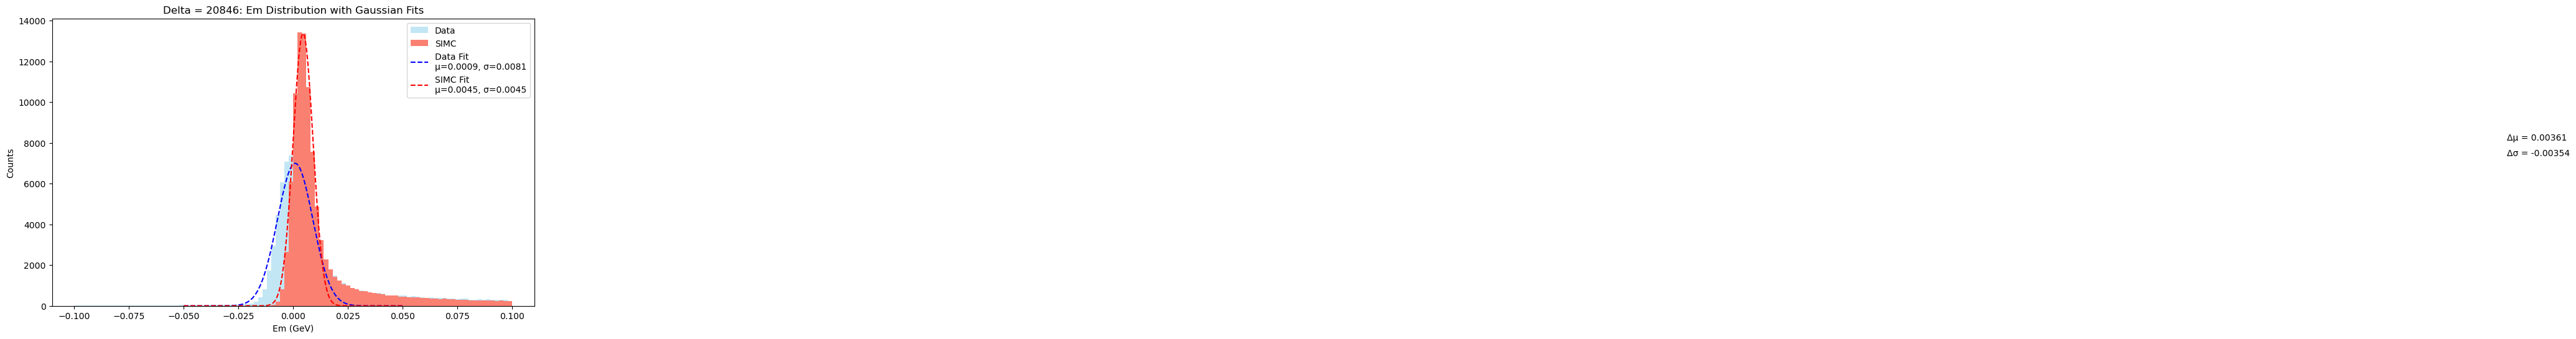

Data Fit:   Mean = 0.00092,  Sigma = 0.00808
SIMC Fit:   Mean = 0.00452,  Sigma = 0.00454
Δ Mean = 0.00361
Δ Sigma = -0.00354
Processing delta = 20851


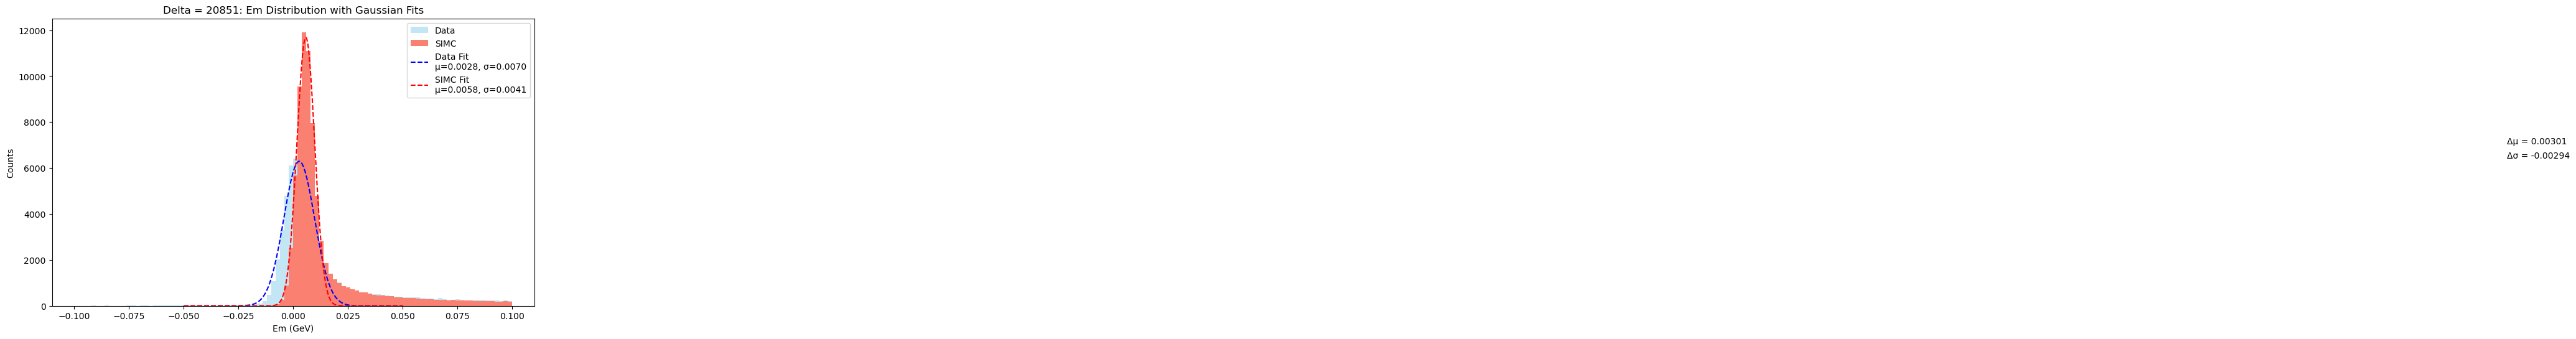

Data Fit:   Mean = 0.00276,  Sigma = 0.00701
SIMC Fit:   Mean = 0.00577,  Sigma = 0.00407
Δ Mean = 0.00301
Δ Sigma = -0.00294
Processing delta = 20858


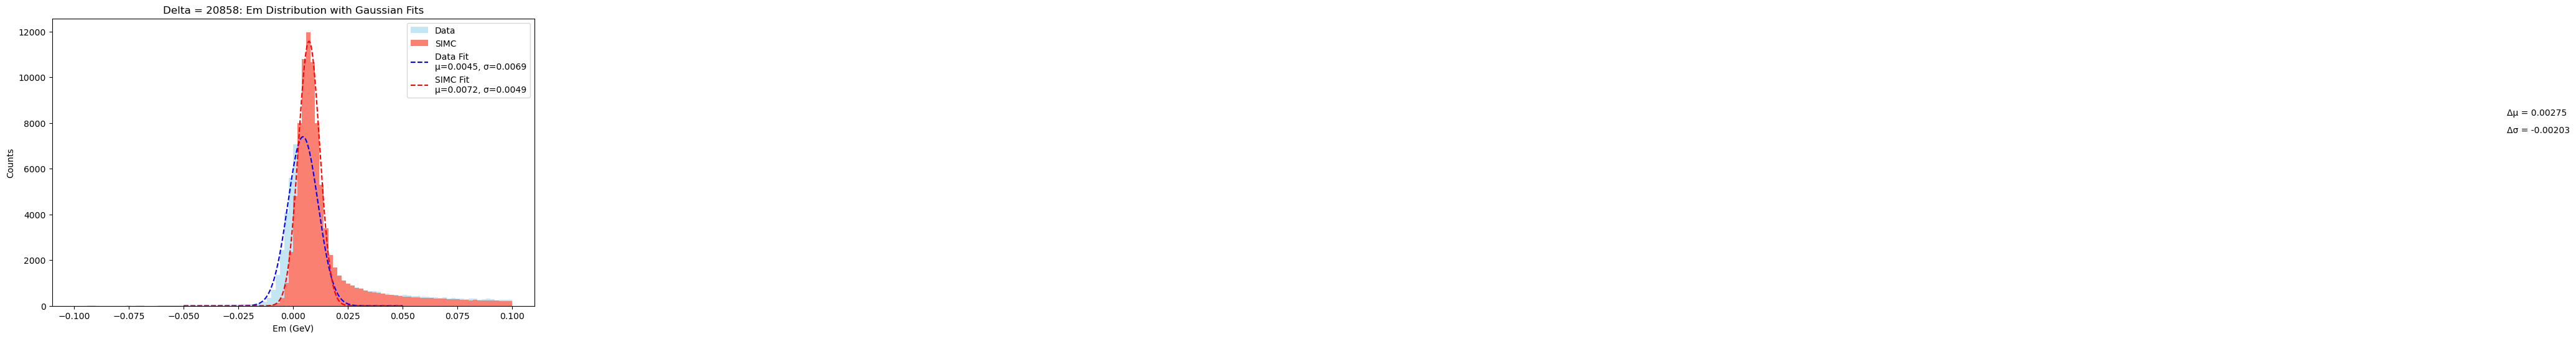

Data Fit:   Mean = 0.00448,  Sigma = 0.00688
SIMC Fit:   Mean = 0.00724,  Sigma = 0.00485
Δ Mean = 0.00275
Δ Sigma = -0.00203
Processing delta = 20861


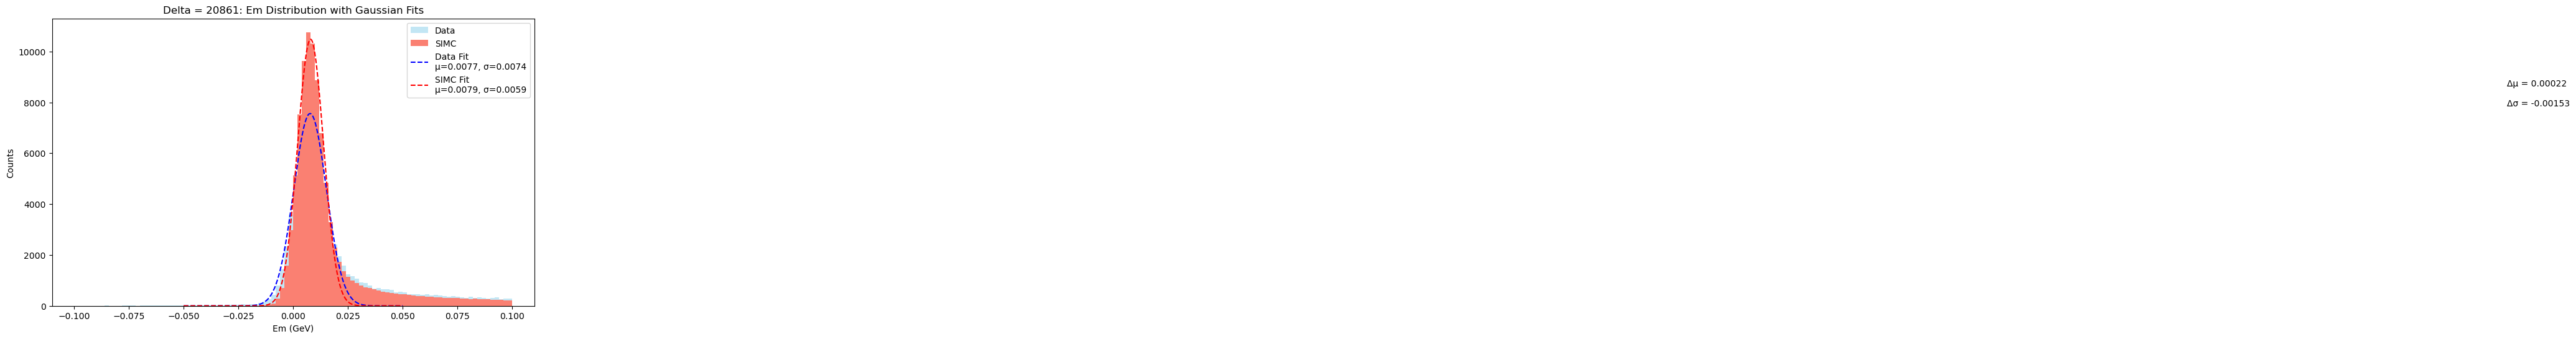

Data Fit:   Mean = 0.00773,  Sigma = 0.00744
SIMC Fit:   Mean = 0.00795,  Sigma = 0.00592
Δ Mean = 0.00022
Δ Sigma = -0.00153
Processing delta = 20869


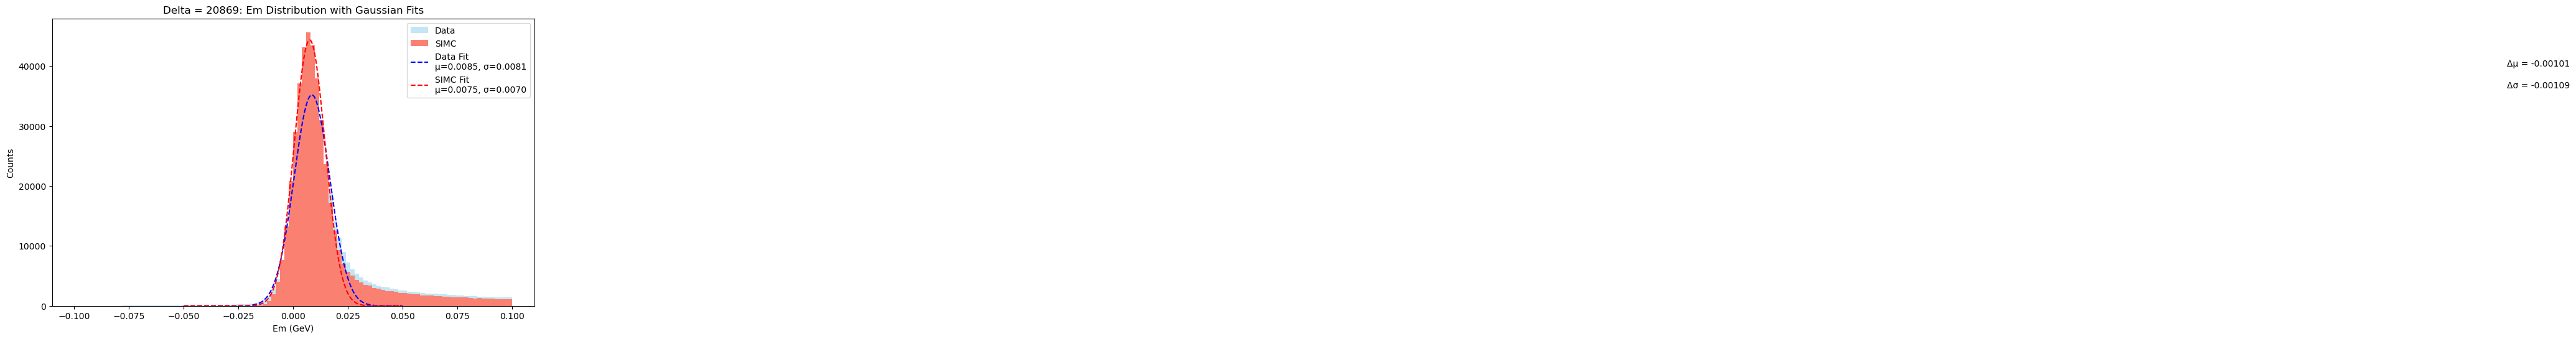

Data Fit:   Mean = 0.00854,  Sigma = 0.00814
SIMC Fit:   Mean = 0.00753,  Sigma = 0.00705
Δ Mean = -0.00101
Δ Sigma = -0.00109
✅ Saved summary to fit_Em_summary.csv


In [11]:
import uproot
import numpy as np
import pandas as pd
import os
from scipy.stats import norm
from scipy.optimize import curve_fit


# List of all delta run configurations
Mp=0.938272

# Gaussian function
def gaussian(x, amplitude, mean, std_dev):
    return amplitude * np.exp(-((x - mean) ** 2) / (2 * std_dev ** 2))

runs = [
    {"Run": 20841, "data_file": "deut_20841.root", "simc_file": "d2_simc_skimmed_-8.root"},
    {"Run": 20846, "data_file": "deut_20846.root", "simc_file": "d2_simc_skimmed_-4.root"},
    {"Run": 20851, "data_file": "deut_20851.root", "simc_file": "d2_simc_skimmed_0.root"},
    {"Run": 20858, "data_file": "deut_20858.root", "simc_file": "d2_simc_skimmed_+4.root"},
    {"Run": 20861, "data_file": "deut_20861.root", "simc_file": "d2_simc_skimmed_+8.root"},
    {"Run": 20869, "data_file": "deut_20869.root", "simc_file": "d2_simc_skimmed_+12.root"},
]

# Initialize list to collect all results
results = []

for run in runs:
    print(f"Processing delta = {run['Run']}")

     # === Load data file ===
    with uproot.open(run["data_file"]) as file_data:
        tree_data = file_data["T"]
        Em_data = tree_data["H.kin.secondary.emiss"].array()
        xbj_data = tree_data["P.kin.primary.x_bj"].array()
        edelta_data = tree_data["P.gtr.dp"].array()
        hdelta_data = tree_data["H.gtr.dp"].array()
    # Apply data mask
    mask_data = (
        (xbj_data >= 0.8) & (xbj_data <= 1.2) &
        (edelta_data <= 22) & (edelta_data >= -10) &
        (hdelta_data <= 10) & (hdelta_data >= -10)
    )

     # === Load SIMC file ===
    with uproot.open(run["simc_file"]) as file_simc:
        tree_simc = file_simc["SNT"]
        Em_simc = tree_simc["Em"].array()
        Q2_simc = tree_simc["Q2"].array()
        nu_simc = tree_simc["nu"].array()
        edelta_simc = tree_simc["e_delta"].array()
        hdelta_simc = tree_simc["h_delta"].array()
        Weight = tree_simc["Weight"].array()
        Norm = tree_simc["Normfac"].array()

    xbj_simc = Q2_simc / (2 * Mp * nu_simc)
    FullWeight = Weight * Norm / 1_000_000

    # Apply SIMC mask
    mask_simc = (
        (xbj_simc >= 0.8) & (xbj_simc <= 1.2) &
        (edelta_simc <= 22) & (edelta_simc >= -10) &
        (hdelta_simc <= 10) & (hdelta_simc >= -10)
    )
     # --- Histogram and Fit ---
    plt.figure(figsize=(10, 6))

    # Scale weights to match data
    scale_factor = np.sum(mask_data) / np.sum(FullWeight[mask_simc])
    FullWeight_scaled = FullWeight * scale_factor

    n_data, bins_data, _ = plt.hist(Em_data[mask_data], bins=100, range=(-0.1, 0.1),
                                    alpha=0.5, label='Data', color='skyblue')

    n_simc, bins_simc, _ = plt.hist(Em_simc[mask_simc], bins=100, range=(-0.1, 0.1),
                                    weights=FullWeight_scaled[mask_simc], label='SIMC', color='salmon')

    # Bin centers
    bin_centers_data = (bins_data[:-1] + bins_data[1:]) / 2
    bin_centers_simc = (bins_simc[:-1] + bins_simc[1:]) / 2

    # Fit guesses
    init_guess_data = [np.max(n_data), bin_centers_data[np.argmax(n_data)], 0.02]
    init_guess_simc = [np.max(n_simc), bin_centers_simc[np.argmax(n_simc)], 0.02]

    # Fit Gaussians
    params_data, _ = curve_fit(gaussian, bin_centers_data, n_data, p0=init_guess_data)
    params_simc, _ = curve_fit(gaussian, bin_centers_simc, n_simc, p0=init_guess_simc)

    amp_data, mean_data, std_data = params_data
    amp_simc, mean_simc, std_simc = params_simc
    mean_diff= mean_data -mean_simc
    std_diff= std_data -std_simc
    # Generate fit curves
    x_fit = np.linspace(-0.05, 0.05, 500)
    y_fit_data = gaussian(x_fit, *params_data)
    y_fit_simc = gaussian(x_fit, *params_simc)
    
    # Plot fits
    plt.plot(x_fit, y_fit_data, 'b--', label=f'Data Fit\nμ={mean_data:.4f}, σ={std_data:.4f}')
    plt.plot(x_fit, y_fit_simc, 'r--', label=f'SIMC Fit\nμ={mean_simc:.4f}, σ={std_simc:.4f}')

        # Annotate
    plt.text(1.01, max(n_data)*1.1, f"Δμ = {mean_simc - mean_data:.5f}", fontsize=10)
    plt.text(1.01, max(n_data)*1., f"Δσ = {std_simc - std_data:.5f}", fontsize=10)

        # Labels and legend
    plt.xlabel('Em (GeV)')
    plt.ylabel('Counts')
    plt.title(f'Delta = {run["Run"]}: Em Distribution with Gaussian Fits')
    plt.legend()
    plt.tight_layout()
    plt.show()
   

    # Print fit values
    print(f"Data Fit:   Mean = {mean_data:.5f},  Sigma = {std_data:.5f}")
    print(f"SIMC Fit:   Mean = {mean_simc:.5f},  Sigma = {std_simc:.5f}")
    print(f"Δ Mean = {mean_simc - mean_data:.5f}")
    print(f"Δ Sigma = {std_simc - std_data:.5f}")
    # --- Store result for this run ---
    results.append({
       "Runs": run["Run"],
        "Em_data": mean_data,
        "Em_simc": mean_simc,
        "Em_data_err": std_data,
        "Em_simc_err": std_simc,
    
    })

# --- Write all results to CSV ---
df = pd.DataFrame(results)
df.to_csv("fit_Em_summary.csv", index=False)
print("✅ Saved summary to fit_Em_summary.csv")
  

In [12]:
df

,Runs,Em_data,Em_simc,Em_data_err,Em_simc_err
0,20841,-0.003201,0.004726,0.009824,0.006932
1,20846,0.000917,0.004524,0.008079,0.004544
2,20851,0.002759,0.005771,0.007007,0.004066
3,20858,0.004481,0.007236,0.006876,0.004851
4,20861,0.007730,0.007950,0.007444,0.005918
5,20869,0.008538,0.007532,0.008141,0.007050


Processing delta = 20841
Data Fit:   Mean = -0.00298,  Sigma = 0.01357
SIMC Fit:   Mean = -0.00028,  Sigma = 0.01211
Δ Mean = 0.00270
Δ Sigma = -0.00146
Processing delta = 20846
Data Fit:   Mean = -0.00544,  Sigma = 0.01132
SIMC Fit:   Mean = -0.00044,  Sigma = 0.01045
Δ Mean = 0.00500
Δ Sigma = -0.00087
Processing delta = 20851
Data Fit:   Mean = -0.00582,  Sigma = 0.01028
SIMC Fit:   Mean = -0.00103,  Sigma = 0.00879
Δ Mean = 0.00479
Δ Sigma = -0.00149
Processing delta = 20858
Data Fit:   Mean = -0.00636,  Sigma = 0.00920
SIMC Fit:   Mean = -0.00140,  Sigma = 0.00740
Δ Mean = 0.00496
Δ Sigma = -0.00180
Processing delta = 20861
Data Fit:   Mean = -0.00676,  Sigma = 0.00895
SIMC Fit:   Mean = -0.00129,  Sigma = 0.00626
Δ Mean = 0.00547
Δ Sigma = -0.00269
Processing delta = 20869
Data Fit:   Mean = -0.00737,  Sigma = 0.00905
SIMC Fit:   Mean = -0.00060,  Sigma = 0.00533
Δ Mean = 0.00677
Δ Sigma = -0.00372
✅ Saved summary to fit_Pmx_summary.csv


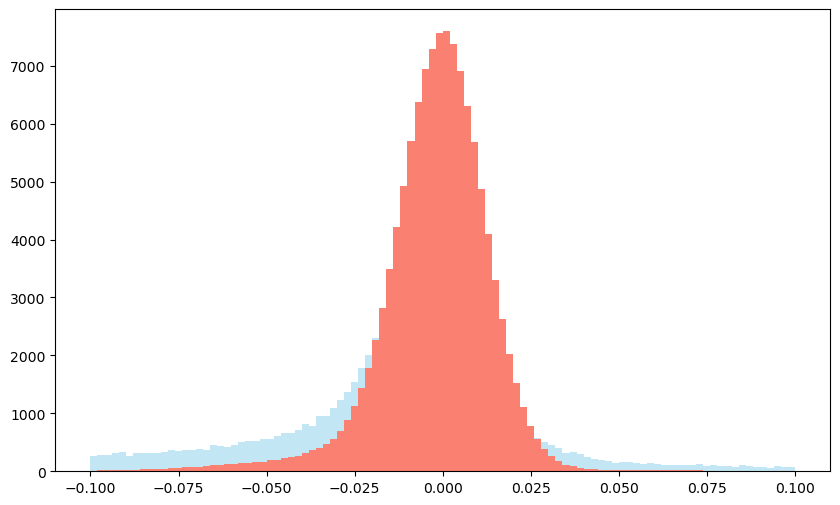

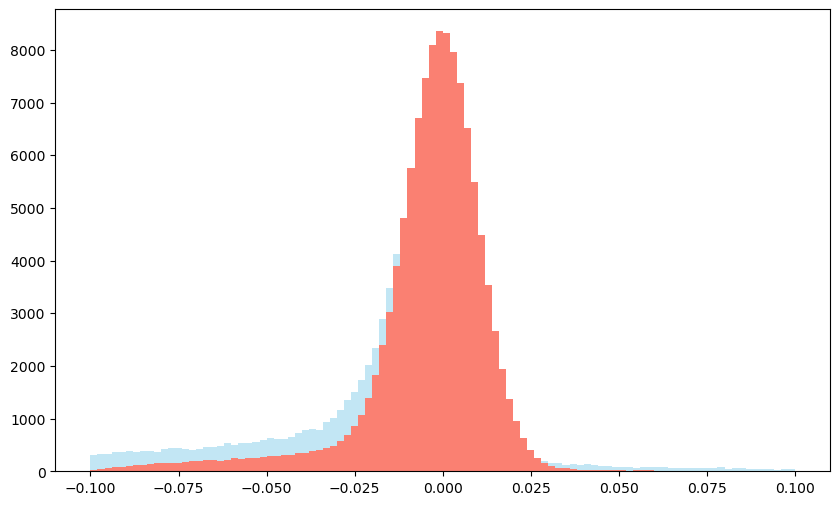

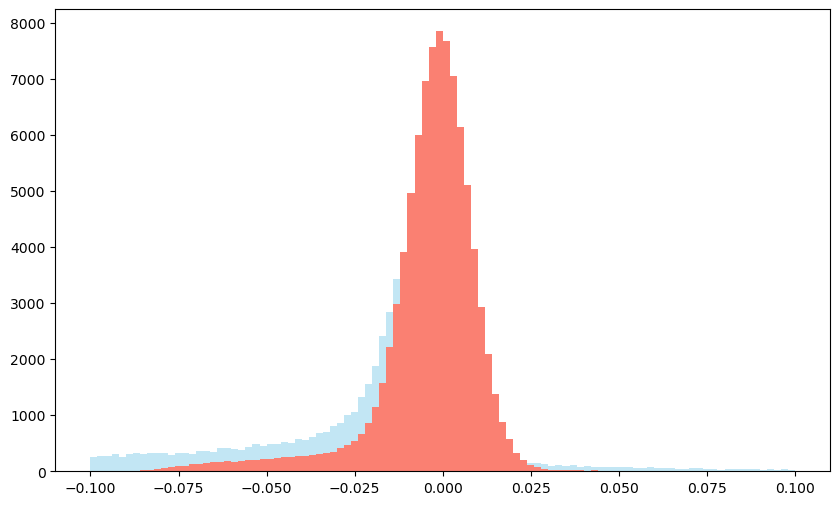

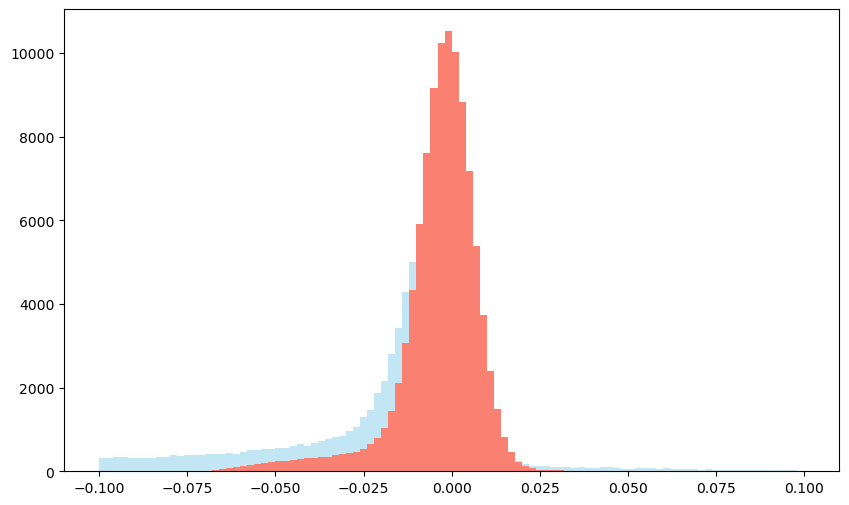

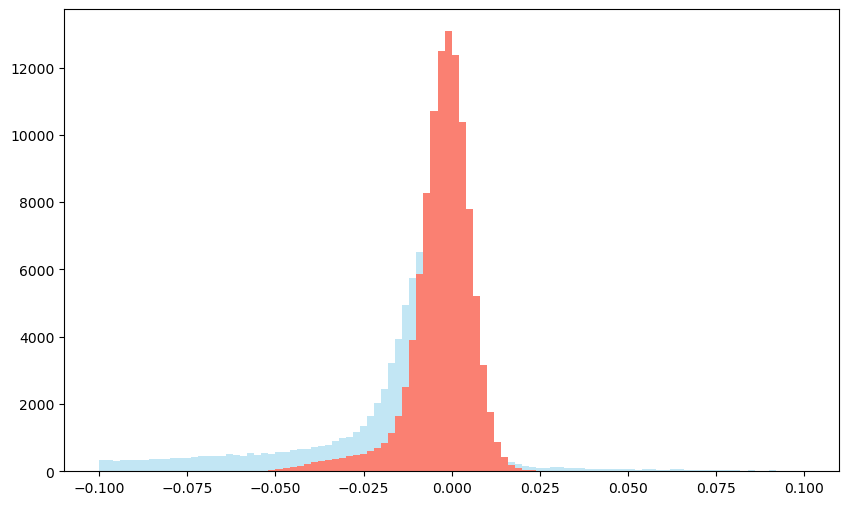

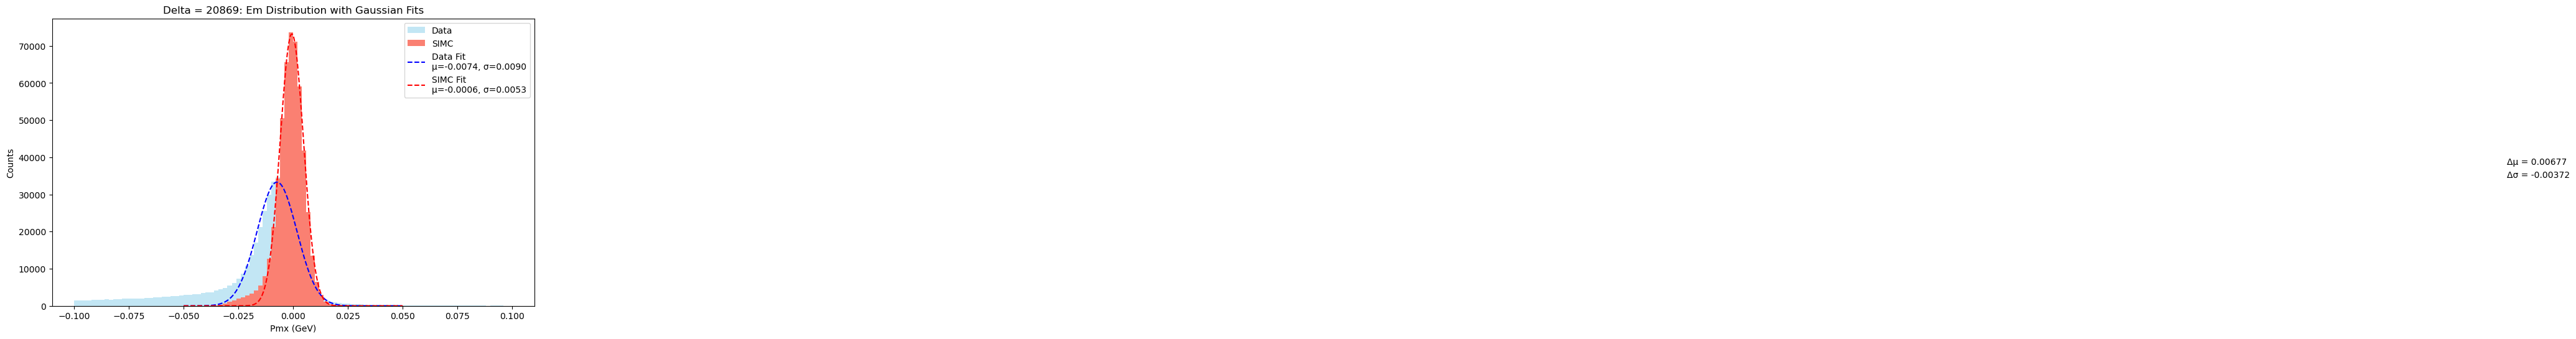

In [15]:
import uproot
import numpy as np
import pandas as pd
import os
from scipy.stats import norm
from scipy.optimize import curve_fit


# List of all delta run configurations
Mp=0.938272

# Gaussian function
def gaussian(x, amplitude, mean, std_dev):
    return amplitude * np.exp(-((x - mean) ** 2) / (2 * std_dev ** 2))

runs = [
    {"Run": 20841, "data_file": "deut_20841.root", "simc_file": "d2_simc_skimmed_-8.root"},
    {"Run": 20846, "data_file": "deut_20846.root", "simc_file": "d2_simc_skimmed_-4.root"},
    {"Run": 20851, "data_file": "deut_20851.root", "simc_file": "d2_simc_skimmed_0.root"},
    {"Run": 20858, "data_file": "deut_20858.root", "simc_file": "d2_simc_skimmed_+4.root"},
    {"Run": 20861, "data_file": "deut_20861.root", "simc_file": "d2_simc_skimmed_+8.root"},
    {"Run": 20869, "data_file": "deut_20869.root", "simc_file": "d2_simc_skimmed_+12.root"},
]

# Initialize list to collect all results
results = []

for run in runs:
    print(f"Processing delta = {run['Run']}")

     # === Load data file ===
    with uproot.open(run["data_file"]) as file_data:
        tree_data = file_data["T"]
        Pmx_data = tree_data["H.kin.secondary.pmiss_x"].array()
        xbj_data = tree_data["P.kin.primary.x_bj"].array()
        edelta_data = tree_data["P.gtr.dp"].array()
        hdelta_data = tree_data["H.gtr.dp"].array()
    # Apply data mask
    mask_data = (
        (xbj_data >= 0.8) & (xbj_data <= 1.2) &
        (edelta_data <= 22) & (edelta_data >= -10) &
        (hdelta_data <= 10) & (hdelta_data >= -10)
    )

     # === Load SIMC file ===
    with uproot.open(run["simc_file"]) as file_simc:
        tree_simc = file_simc["SNT"]
        Pmx_simc = tree_simc["Pmx"].array()
        Q2_simc = tree_simc["Q2"].array()
        nu_simc = tree_simc["nu"].array()
        edelta_simc = tree_simc["e_delta"].array()
        hdelta_simc = tree_simc["h_delta"].array()
        Weight = tree_simc["Weight"].array()
        Norm = tree_simc["Normfac"].array()

    xbj_simc = Q2_simc / (2 * Mp * nu_simc)
    FullWeight = Weight * Norm / 1_000_000

    # Apply SIMC mask
    mask_simc = (
        (xbj_simc >= 0.8) & (xbj_simc <= 1.2) &
        (edelta_simc <= 22) & (edelta_simc >= -10) &
        (hdelta_simc <= 10) & (hdelta_simc >= -10)
    )
     # --- Histogram and Fit ---
    plt.figure(figsize=(10, 6))

    # Scale weights to match data
    scale_factor = np.sum(mask_data) / np.sum(FullWeight[mask_simc])
    FullWeight_scaled = FullWeight * scale_factor

    n_data, bins_data, _ = plt.hist(Pmx_data[mask_data], bins=100, range=(-0.1, 0.1),
                                    alpha=0.5, label='Data', color='skyblue')

    n_simc, bins_simc, _ = plt.hist(Pmx_simc[mask_simc], bins=100, range=(-0.1, 0.1),
                                    weights=FullWeight_scaled[mask_simc], label='SIMC', color='salmon')

    # Bin centers
    bin_centers_data = (bins_data[:-1] + bins_data[1:]) / 2
    bin_centers_simc = (bins_simc[:-1] + bins_simc[1:]) / 2

    # Fit guesses
    init_guess_data = [np.max(n_data), bin_centers_data[np.argmax(n_data)], 0.02]
    init_guess_simc = [np.max(n_simc), bin_centers_simc[np.argmax(n_simc)], 0.02]

    # Fit Gaussians
    params_data, _ = curve_fit(gaussian, bin_centers_data, n_data, p0=init_guess_data)
    params_simc, _ = curve_fit(gaussian, bin_centers_simc, n_simc, p0=init_guess_simc)

    amp_data, mean_data, std_data = params_data
    amp_simc, mean_simc, std_simc = params_simc
    mean_diff= mean_data -mean_simc
    std_diff= std_data -std_simc
    # Generate fit curves
    x_fit = np.linspace(-0.05, 0.05, 500)
    y_fit_data = gaussian(x_fit, *params_data)
    y_fit_simc = gaussian(x_fit, *params_simc)
    
   

    # Print fit values
    print(f"Data Fit:   Mean = {mean_data:.5f},  Sigma = {std_data:.5f}")
    print(f"SIMC Fit:   Mean = {mean_simc:.5f},  Sigma = {std_simc:.5f}")
    print(f"Δ Mean = {mean_simc - mean_data:.5f}")
    print(f"Δ Sigma = {std_simc - std_data:.5f}")
    # --- Store result for this run ---
    results.append({
       "Runs": run["Run"],
        "Pmx_data": mean_data,
        "Pmx_simc": mean_simc,
        "Pmx_data_err": std_data,
        "Pmx_simc_err": std_simc,
       
    })

# --- Write all results to CSV ---
df = pd.DataFrame(results)
df.to_csv("fit_Pmx_summary.csv", index=False)
print("✅ Saved summary to fit_Pmx_summary.csv")
  # Plot fits
plt.plot(x_fit, y_fit_data, 'b--', label=f'Data Fit\nμ={mean_data:.4f}, σ={std_data:.4f}')
plt.plot(x_fit, y_fit_simc, 'r--', label=f'SIMC Fit\nμ={mean_simc:.4f}, σ={std_simc:.4f}')

    # Annotate
plt.text(1.01, max(n_data)*1.1, f"Δμ = {mean_simc - mean_data:.5f}", fontsize=10)
plt.text(1.01, max(n_data)*1., f"Δσ = {std_simc - std_data:.5f}", fontsize=10)

    # Labels and legend
plt.xlabel('Pmx (GeV)')
plt.ylabel('Counts')
plt.title(f'Delta = {run["Run"]}: Em Distribution with Gaussian Fits')
plt.legend()
#plt.tight_layout()
plt.show()

In [16]:
df

,Runs,Pmx_data,Pmx_simc,Pmx_data_err,Pmx_simc_err
0,20841,-0.002979,-0.000278,0.013570,0.012109
1,20846,-0.005439,-0.000443,0.011316,0.010449
2,20851,-0.005823,-0.001031,0.010280,0.008790
3,20858,-0.006365,-0.001402,0.009204,0.007400
4,20861,-0.006764,-0.001295,0.008949,0.006259
5,20869,-0.007371,-0.000602,0.009047,0.005330


Processing delta = 20841


/var/folders/2h/5v3tch6n7735dls3wck0tbr00000gn/T/ipykernel_16938/4165129838.py:112: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


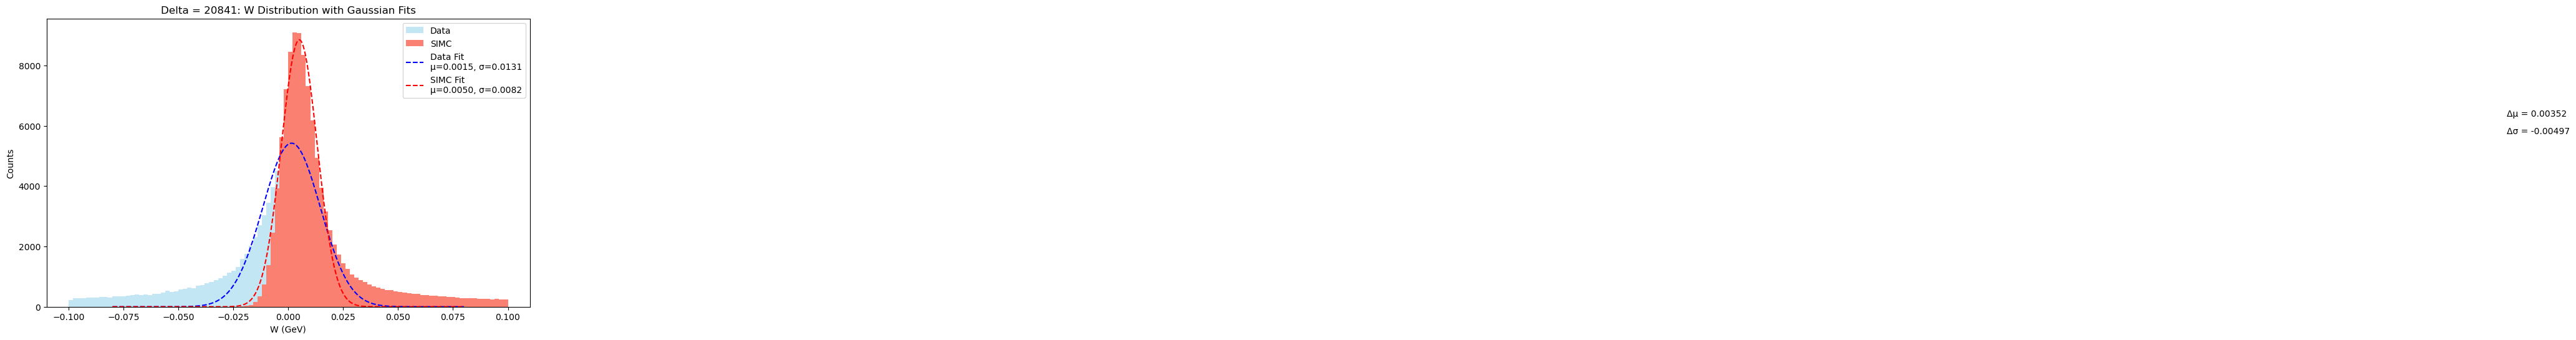

Data Fit:   Mean = 0.00151,  Sigma = 0.01312
SIMC Fit:   Mean = 0.00503,  Sigma = 0.00815
Δ Mean = 0.00352
Δ Sigma = -0.00497
Processing delta = 20846


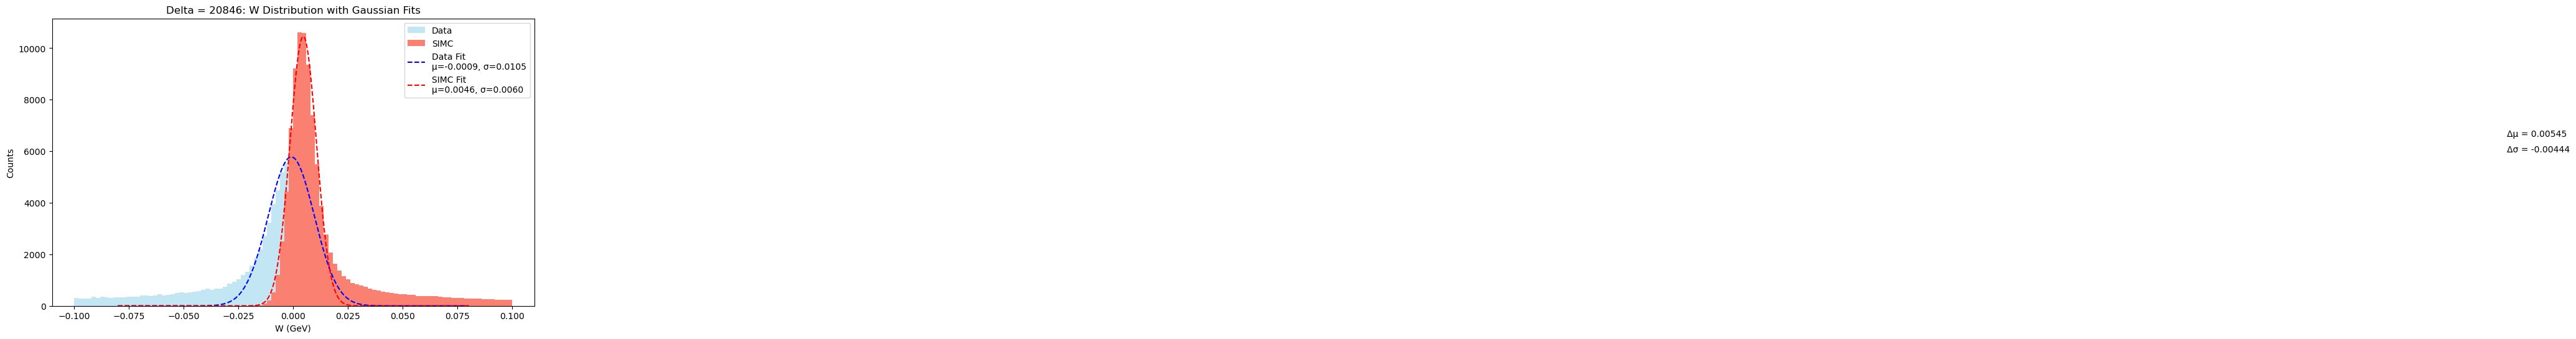

Data Fit:   Mean = -0.00085,  Sigma = 0.01047
SIMC Fit:   Mean = 0.00460,  Sigma = 0.00603
Δ Mean = 0.00545
Δ Sigma = -0.00444
Processing delta = 20851


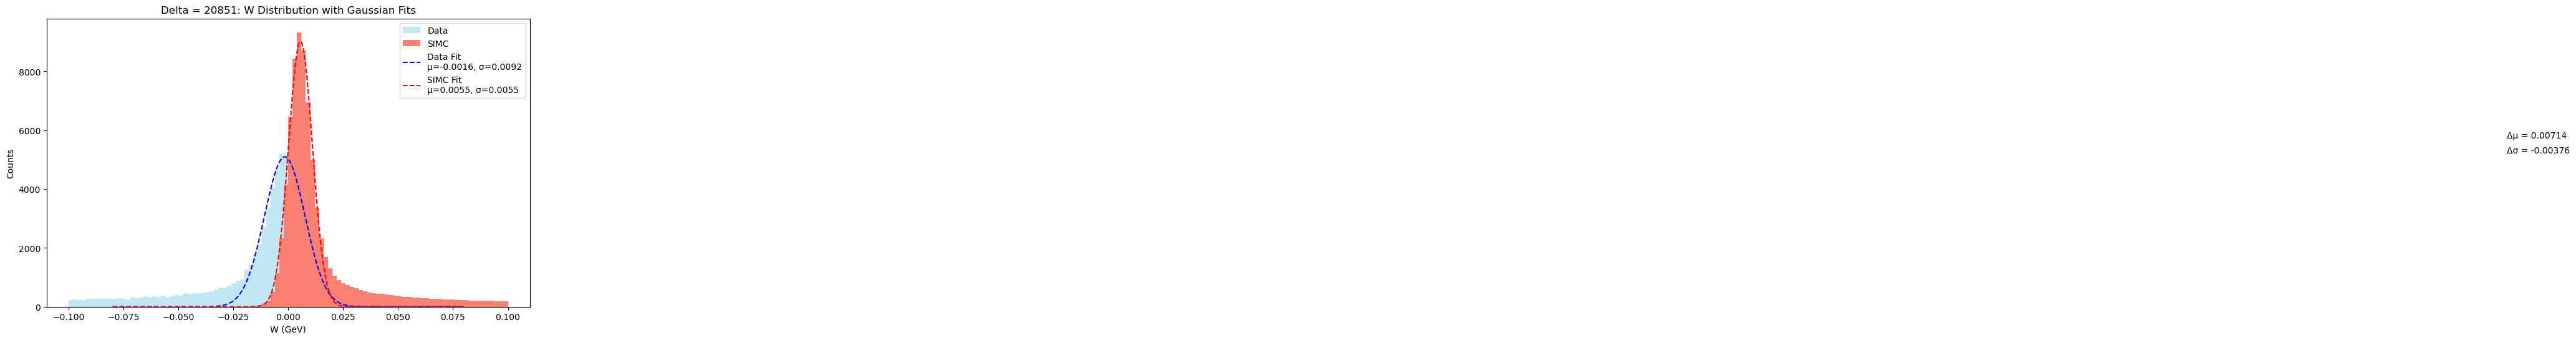

Data Fit:   Mean = -0.00159,  Sigma = 0.00922
SIMC Fit:   Mean = 0.00555,  Sigma = 0.00545
Δ Mean = 0.00714
Δ Sigma = -0.00376
Processing delta = 20858


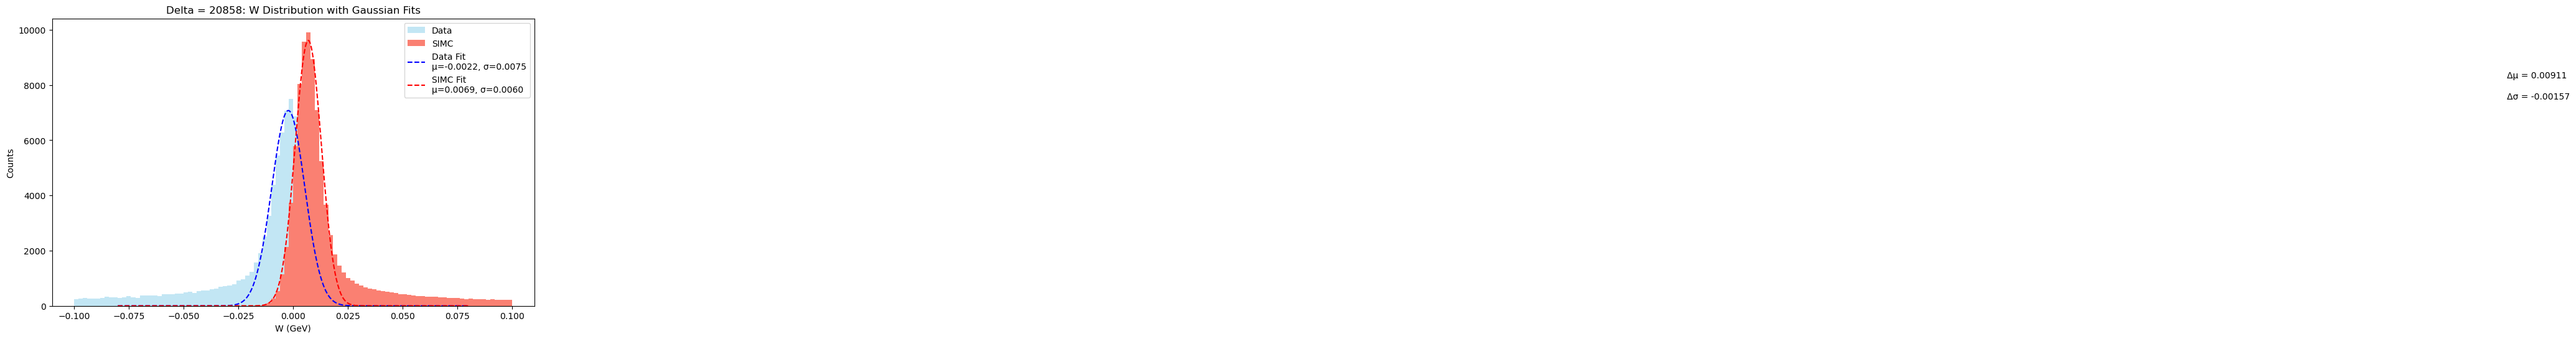

Data Fit:   Mean = -0.00221,  Sigma = 0.00754
SIMC Fit:   Mean = 0.00690,  Sigma = 0.00598
Δ Mean = 0.00911
Δ Sigma = -0.00157
Processing delta = 20861


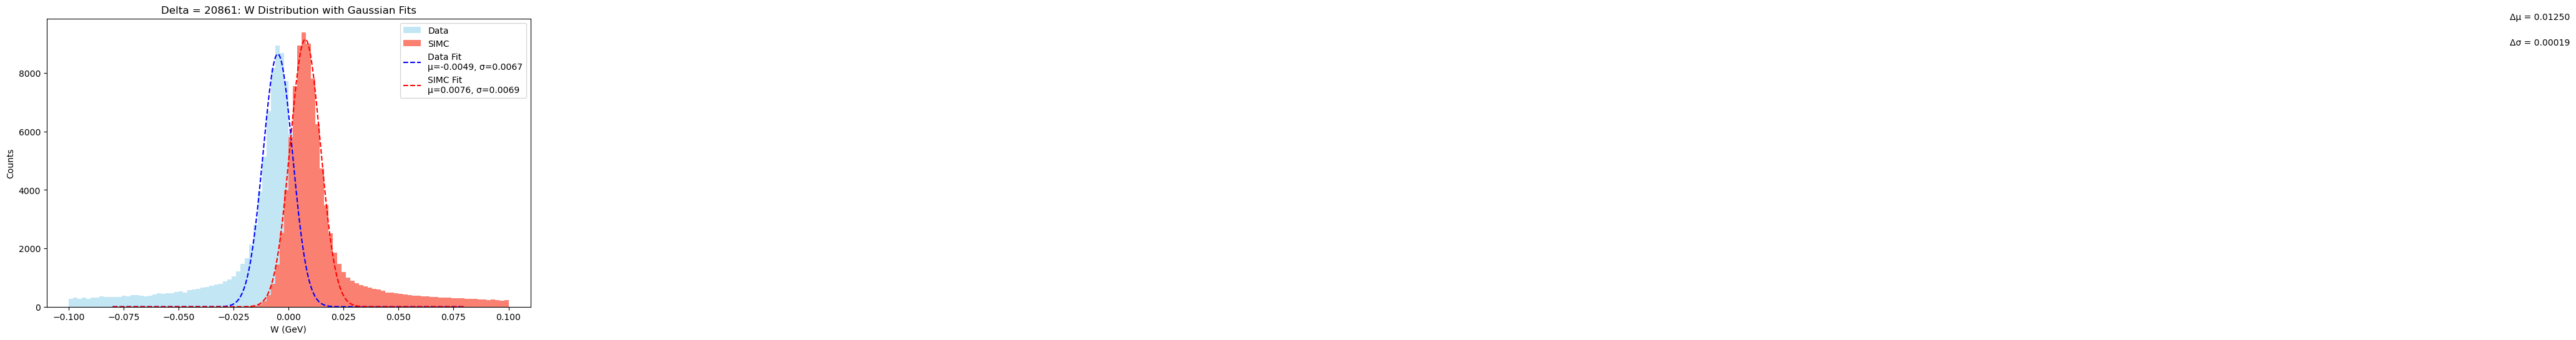

Data Fit:   Mean = -0.00492,  Sigma = 0.00670
SIMC Fit:   Mean = 0.00757,  Sigma = 0.00689
Δ Mean = 0.01250
Δ Sigma = 0.00019
Processing delta = 20869


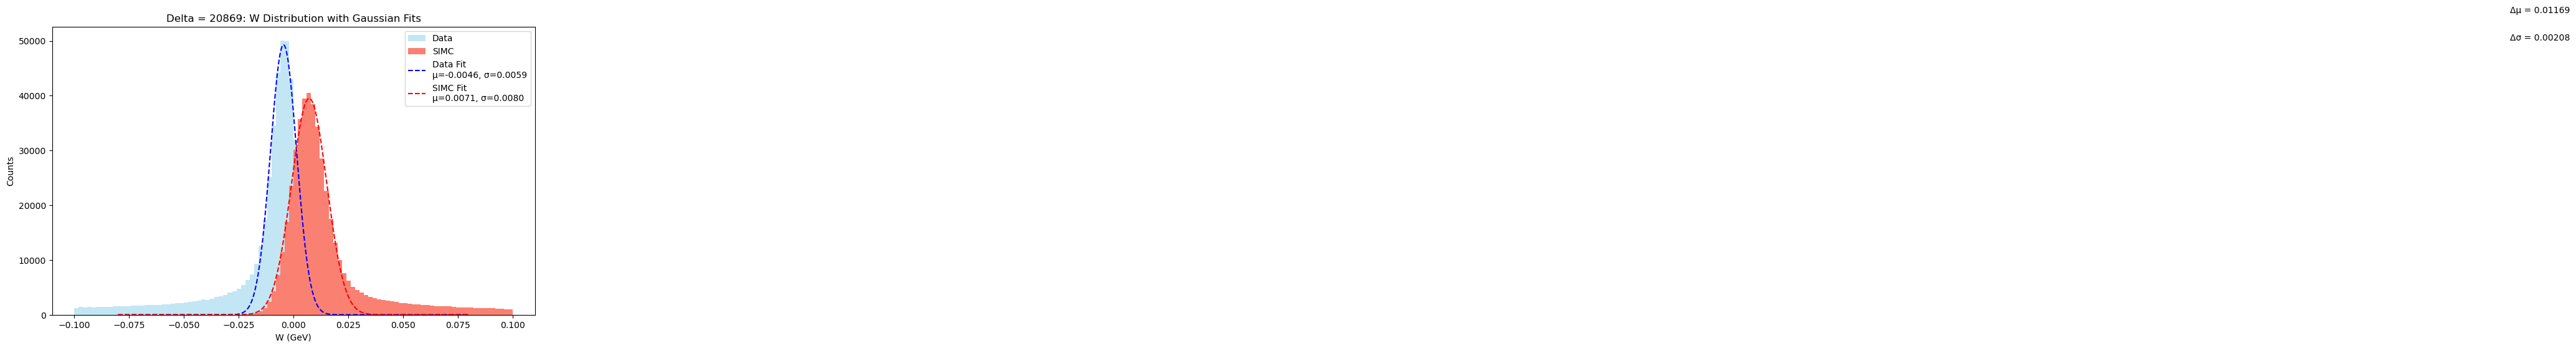

Data Fit:   Mean = -0.00455,  Sigma = 0.00594
SIMC Fit:   Mean = 0.00714,  Sigma = 0.00802
Δ Mean = 0.01169
Δ Sigma = 0.00208
✅ Saved summary to fit_Pmz_summary.csv


In [17]:
import uproot
import numpy as np
import pandas as pd
import os
from scipy.stats import norm
from scipy.optimize import curve_fit


# List of all delta run configurations
Mp=0.938272

# Gaussian function
def gaussian(x, amplitude, mean, std_dev):
    return amplitude * np.exp(-((x - mean) ** 2) / (2 * std_dev ** 2))

runs = [
    {"Run": 20841, "data_file": "deut_20841.root", "simc_file": "d2_simc_skimmed_-8.root"},
    {"Run": 20846, "data_file": "deut_20846.root", "simc_file": "d2_simc_skimmed_-4.root"},
    {"Run": 20851, "data_file": "deut_20851.root", "simc_file": "d2_simc_skimmed_0.root"},
    {"Run": 20858, "data_file": "deut_20858.root", "simc_file": "d2_simc_skimmed_+4.root"},
    {"Run": 20861, "data_file": "deut_20861.root", "simc_file": "d2_simc_skimmed_+8.root"},
    {"Run": 20869, "data_file": "deut_20869.root", "simc_file": "d2_simc_skimmed_+12.root"},
]

# Initialize list to collect all results
results = []

for run in runs:
    print(f"Processing delta = {run['Run']}")

     # === Load data file ===
    with uproot.open(run["data_file"]) as file_data:
        tree_data = file_data["T"]
        Pmz_data = tree_data["H.kin.secondary.pmiss_z"].array()
        xbj_data = tree_data["P.kin.primary.x_bj"].array()
        edelta_data = tree_data["P.gtr.dp"].array()
        hdelta_data = tree_data["H.gtr.dp"].array()
    # Apply data mask
    mask_data = (
        (xbj_data >= 0.8) & (xbj_data <= 1.2) &
        (edelta_data <= 22) & (edelta_data >= -10) &
        (hdelta_data <= 10) & (hdelta_data >= -10)
    )

     # === Load SIMC file ===
    with uproot.open(run["simc_file"]) as file_simc:
        tree_simc = file_simc["SNT"]
        Pmz_simc = tree_simc["Pmz"].array()
        Q2_simc = tree_simc["Q2"].array()
        nu_simc = tree_simc["nu"].array()
        edelta_simc = tree_simc["e_delta"].array()
        hdelta_simc = tree_simc["h_delta"].array()
        Weight = tree_simc["Weight"].array()
        Norm = tree_simc["Normfac"].array()

    xbj_simc = Q2_simc / (2 * Mp * nu_simc)
    FullWeight = Weight * Norm / 1_000_000

    # Apply SIMC mask
    mask_simc = (
        (xbj_simc >= 0.8) & (xbj_simc <= 1.2) &
        (edelta_simc <= 22) & (edelta_simc >= -10) &
        (hdelta_simc <= 10) & (hdelta_simc >= -10)
    )
     # --- Histogram and Fit ---
    plt.figure(figsize=(10, 6))

    # Scale weights to match data
    scale_factor = np.sum(mask_data) / np.sum(FullWeight[mask_simc])
    FullWeight_scaled = FullWeight * scale_factor

    n_data, bins_data, _ = plt.hist(Pmz_data[mask_data], bins=100, range=(-0.1, 0.1),
                                    alpha=0.5, label='Data', color='skyblue')

    n_simc, bins_simc, _ = plt.hist(Pmz_simc[mask_simc], bins=100, range=(-0.1, 0.1),
                                    weights=FullWeight_scaled[mask_simc], label='SIMC', color='salmon')

    # Bin centers
    bin_centers_data = (bins_data[:-1] + bins_data[1:]) / 2
    bin_centers_simc = (bins_simc[:-1] + bins_simc[1:]) / 2

    # Fit guesses
    init_guess_data = [np.max(n_data), bin_centers_data[np.argmax(n_data)], 0.02]
    init_guess_simc = [np.max(n_simc), bin_centers_simc[np.argmax(n_simc)], 0.02]

    # Fit Gaussians
    params_data, _ = curve_fit(gaussian, bin_centers_data, n_data, p0=init_guess_data)
    params_simc, _ = curve_fit(gaussian, bin_centers_simc, n_simc, p0=init_guess_simc)

    amp_data, mean_data, std_data = params_data
    amp_simc, mean_simc, std_simc = params_simc
    mean_diff= mean_data -mean_simc
    std_diff= std_data -std_simc
    # Generate fit curves
    x_fit = np.linspace(-0.08, 0.08, 500)
    y_fit_data = gaussian(x_fit, *params_data)
    y_fit_simc = gaussian(x_fit, *params_simc)
    
     # Plot fits
    plt.plot(x_fit, y_fit_data, 'b--', label=f'Data Fit\nμ={mean_data:.4f}, σ={std_data:.4f}')
    plt.plot(x_fit, y_fit_simc, 'r--', label=f'SIMC Fit\nμ={mean_simc:.4f}, σ={std_simc:.4f}')

    # Annotate
    plt.text(1.01, max(n_data)*1.1, f"Δμ = {mean_simc - mean_data:.5f}", fontsize=10)
    plt.text(1.01, max(n_data)*1., f"Δσ = {std_simc - std_data:.5f}", fontsize=10)

    # Labels and legend
    plt.xlabel('W (GeV)')
    plt.ylabel('Counts')
    plt.title(f'Delta = {run["Run"]}: W Distribution with Gaussian Fits')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Print fit values
    print(f"Data Fit:   Mean = {mean_data:.5f},  Sigma = {std_data:.5f}")
    print(f"SIMC Fit:   Mean = {mean_simc:.5f},  Sigma = {std_simc:.5f}")
    print(f"Δ Mean = {mean_simc - mean_data:.5f}")
    print(f"Δ Sigma = {std_simc - std_data:.5f}")
    # --- Store result for this run ---
    results.append({
        "Runs": run["Run"],
        "Pmz_data": mean_data,
        "Pmz_simc": mean_simc,
        "Pmz_data_err": std_data,
        "Pmz_simc_err": std_simc,
       
    })

# --- Write all results to CSV ---
df = pd.DataFrame(results)
df.to_csv("fit_Pmz_summary.csv", index=False)
print("✅ Saved summary to fit_Pmz_summary.csv")


In [19]:
df

,Runs,Pmz_data,Pmz_simc,Pmz_data_err,Pmz_simc_err
0,20841,0.001507,0.005025,0.013120,0.008155
1,20846,-0.000850,0.004597,0.010469,0.006031
2,20851,-0.001592,0.005548,0.009215,0.005451
3,20858,-0.002213,0.006898,0.007545,0.005977
4,20861,-0.004923,0.007574,0.006697,0.006892
5,20869,-0.004553,0.007141,0.005941,0.008022
